# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [1]:
# Import necessary libraries
import os, re, json, random, string, pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch

# --- GPU CONFIGURATION ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"TensorFlow using {len(gpus)} GPU(s): {[g.name for g in gpus]}")
else:
    print("No GPU found for TensorFlow — running on CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {device}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

No GPU found for TensorFlow — running on CPU.
PyTorch device: cpu


Classes (9): ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
                 class  count
6              Plastic    921
3                Metal    790
5                Paper    500
4  Miscellaneous Trash    495
0            Cardboard    461
8           Vegetation    436
2                Glass    420
1        Food Organics    411
7        Textile Trash    318


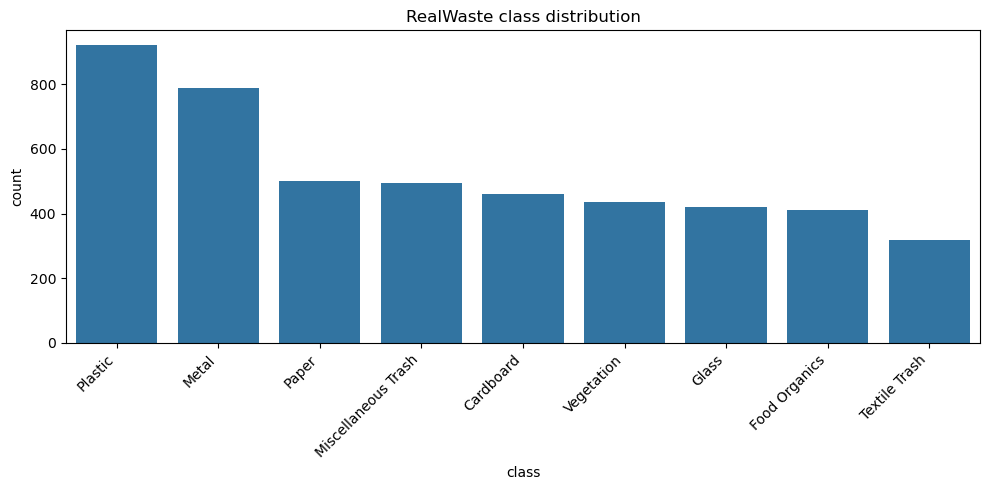

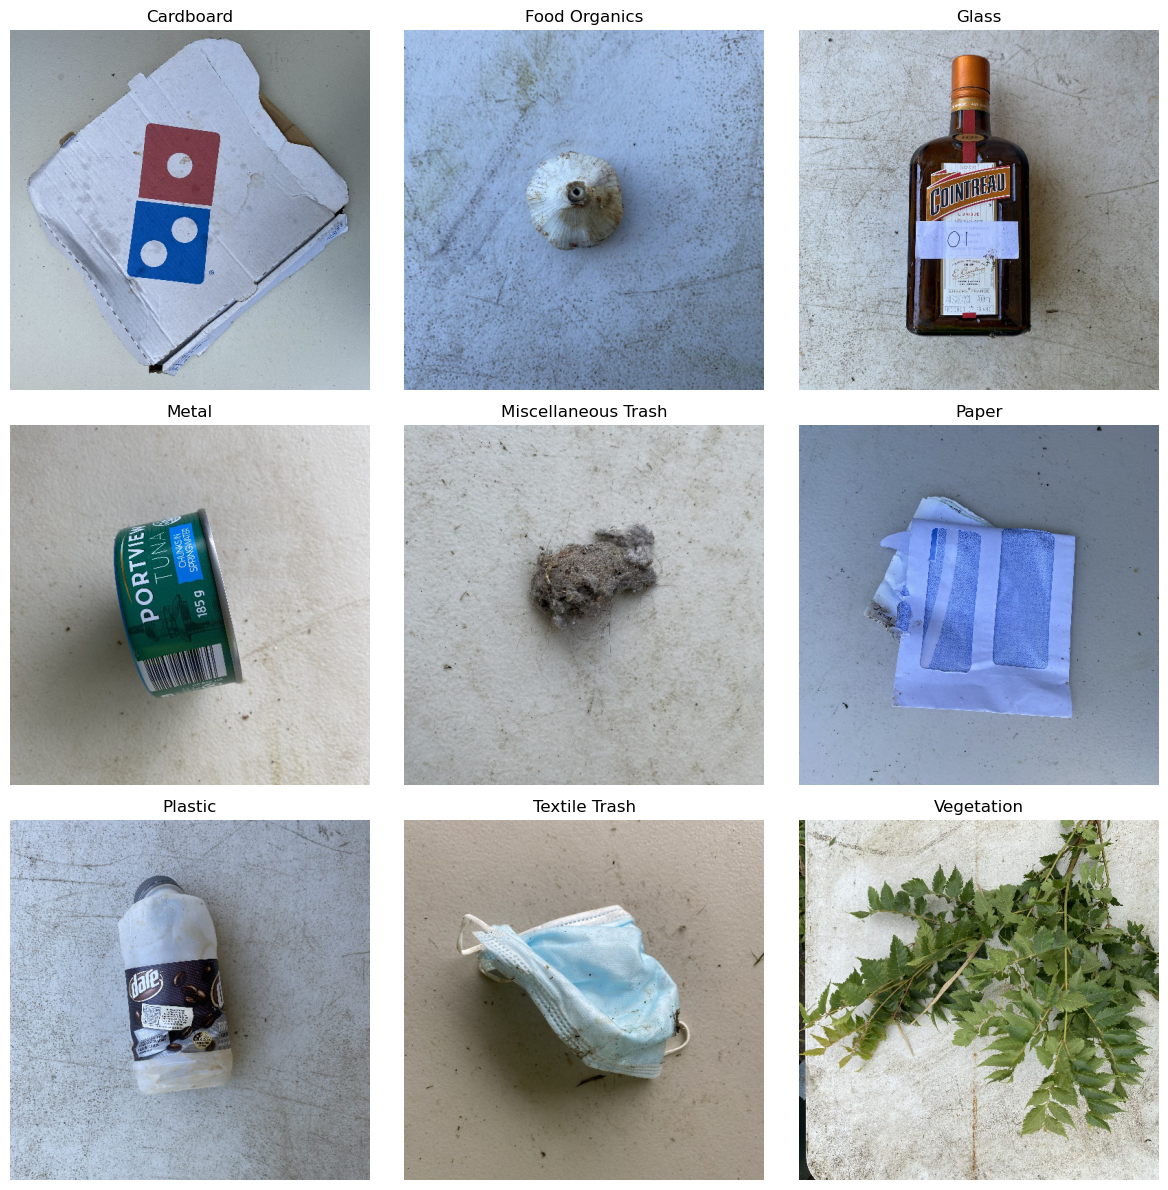

                 class        size mode
0            Cardboard  (524, 524)  RGB
1        Food Organics  (524, 524)  RGB
2                Glass  (524, 524)  RGB
3                Metal  (524, 524)  RGB
4  Miscellaneous Trash  (524, 524)  RGB
5                Paper  (524, 524)  RGB
6              Plastic  (524, 524)  RGB
7        Textile Trash  (524, 524)  RGB
8           Vegetation  (524, 524)  RGB
       width  height
count  180.0   180.0
mean   524.0   524.0
std      0.0     0.0
min    524.0   524.0
25%    524.0   524.0
50%    524.0   524.0
75%    524.0   524.0
max    524.0   524.0


In [3]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)

data_dir = pathlib.Path('data/realwaste-main/RealWaste')
class_names_explore = sorted([d.name for d in data_dir.glob('*') if d.is_dir()])
print(f"Classes ({len(class_names_explore)}): {class_names_explore}")

counts = {c: len(list((data_dir/c).glob('*.jpg')) + list((data_dir/c).glob('*.png')))
          for c in class_names_explore}
count_df = pd.DataFrame(counts.items(), columns=['class', 'count']).sort_values('count', ascending=False)
print(count_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=count_df, x='class', y='count')
plt.xticks(rotation=45, ha='right')
plt.title('RealWaste class distribution')
plt.tight_layout()
plt.show()

# Sample grid + basic stats (resolution, color mode)
sample_info = []
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, c in zip(axes.flat, class_names_explore):
    imgs = list((data_dir/c).glob('*.jpg')) + list((data_dir/c).glob('*.png'))
    p = random.choice(imgs)
    with Image.open(p) as im:
        sample_info.append({'class': c, 'size': im.size, 'mode': im.mode})
        ax.imshow(im)
    ax.set_title(c); ax.axis('off')
plt.tight_layout(); plt.show()
print(pd.DataFrame(sample_info))

# Resolution spread across a larger sample (checks whether images are pre-uniform)
sizes = []
for c in class_names_explore:
    for p in (list((data_dir/c).glob('*.jpg')) + list((data_dir/c).glob('*.png')))[:20]:
        with Image.open(p) as im:
            sizes.append(im.size)
print(pd.DataFrame(sizes, columns=['width', 'height']).describe())

### 1.2 Explore Text Datasets

In [5]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

desc_df = pd.read_csv('data/waste_descriptions.csv')
print(desc_df.columns.tolist())
print(desc_df.shape)
print(desc_df.head())
print(desc_df['category'].value_counts()) 

all_text = " ".join(desc_df['description'].astype(str))  
words = all_text.lower().split()
print(f"Vocabulary size: {len(set(words))}")
print(f"Avg description length: {np.mean([len(d.split()) for d in desc_df['description'].astype(str)]):.1f} words")

['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']
(5000, 5)
                                         description       category  \
0                           soiled silver tablecloth  Textile Trash   
1                        folded glass bottle leaking          Glass   
2  large Supermarket vegetable waste with food re...  Food Organics   
3                         intact floral carpet piece  Textile Trash   
4                  empty fun-sized purple apple core  Food Organics   

                                disposal_instruction  \
0  Look for textile recycling programs in your area.   
1     Remove caps, lids, and corks before recycling.   
2   If no compost available, place in general waste.   
3  Look for textile recycling programs in your area.   
4           Keep separate from recyclable materials.   

                                    common_confusion  \
0                                                NaN   
1                 

In [7]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.csv
# - Understand document organization and language

with open('data/waste_policy_documents.json') as f:
    policy_data = json.load(f)

print(type(policy_data))
if isinstance(policy_data, list):
    print(f"{len(policy_data)} documents")
    print(policy_data[0])
else:
    print(policy_data.keys())

<class 'list'>
14 documents
{'policy_id': 1, 'policy_type': 'Textile Trash Recycling Guidelines', 'categories_covered': ['Textile Trash'], 'effective_date': '2023-11-04', 'document_text': 'TEXTILE RECYCLING GUIDELINES\n\nAcceptable Items:\n- Clean clothing (all conditions)\n- Towels, sheets, and linens\n- Fabric scraps\n- Curtains and cloth napkins\n- Handbags and backpacks made of fabric\n- Soft toys and stuffed animals\n\nNon-Acceptable Items:\n- Wet or moldy textiles\n- Heavily soiled items\n- Carpets and rugs\n- Footwear\n- Items with significant non-textile parts\n\nCollection Method:\nPlace items in dedicated textile recycling bins or donate to local thrift stores.\n\nPreparation Instructions:\n- Ensure all items are clean and dry\n- Remove non-textile components when possible\n- Bag similar items together\n\nBenefits:\nTextile recycling conserves resources and reduces landfill waste.', 'jurisdiction': 'Metro City'}


### 1.3 Create Data Pipelines

In [8]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib
data_dir = pathlib.Path('data/realwaste-main/RealWaste')

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752
Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


In [9]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

desc_df['clean_description'] = desc_df['description'].apply(clean_text)

X_train_text, X_temp_text, y_train_text, y_temp_text = train_test_split(
    desc_df['clean_description'], desc_df['category'],
    test_size=0.3, random_state=42, stratify=desc_df['category']
)
X_val_text, X_test_text, y_val_text, y_test_text = train_test_split(
    X_temp_text, y_temp_text, test_size=0.5, random_state=42, stratify=y_temp_text
)
print(f"Train: {len(X_train_text)}, Val: {len(X_val_text)}, Test: {len(X_test_text)}")

text_label_encoder = LabelEncoder().fit(desc_df['category'])
y_train_enc = text_label_encoder.transform(y_train_text)
y_val_enc   = text_label_encoder.transform(y_val_text)
y_test_enc  = text_label_encoder.transform(y_test_text)

Train: 3500, Val: 750, Test: 750


In [12]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F

# 1) Policy documents — explode categories_covered so each doc is retrievable per category
policy_chunks = []
for doc in policy_data:
    for cat in doc['categories_covered']:
        policy_chunks.append({
            'source': 'policy',
            'category': cat,
            'text': doc['document_text'],
            'policy_type': doc['policy_type']
        })

# 2) Per-category disposal instructions + material composition from the description dataset
#    (aggregate unique instructions per category so we don't duplicate near-identical rows 5000x)
agg = (desc_df.groupby('category')
       .agg({'disposal_instruction': lambda x: list(pd.unique(x)),
             'material_composition': lambda x: list(pd.unique(x))[:3]})  # cap for brevity
       .reset_index())

for _, row in agg.iterrows():
    disposal_text = " ".join(row['disposal_instruction'])
    material_text = " ".join(row['material_composition'])
    combined = f"Disposal guidance for {row['category']}: {disposal_text} Material composition notes: {material_text}"
    policy_chunks.append({
        'source': 'description_dataset',
        'category': row['category'],
        'text': combined,
        'policy_type': 'disposal_instructions'
    })

policy_chunks_df = pd.DataFrame(policy_chunks)
print(policy_chunks_df.shape)
print(policy_chunks_df['category'].value_counts())

# 3) Embed with a plain transformers model (avoids the sentence-transformers/aiohttp crash)
embed_tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
embed_model = AutoModel.from_pretrained('sentence-transformers/all-MiniLM-L6-v2').to(device)
embed_model.eval()

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * mask, 1) / torch.clamp(mask.sum(1), min=1e-9)

def embed_texts(texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = embed_tokenizer(batch, padding=True, truncation=True,
                               max_length=256, return_tensors='pt').to(device)
        with torch.no_grad():
            model_output = embed_model(**enc)
        emb = mean_pooling(model_output, enc['attention_mask'])
        emb = F.normalize(emb, p=2, dim=1)
        all_embeddings.append(emb.cpu().numpy())
    return np.concatenate(all_embeddings, axis=0)

policy_embeddings = embed_texts(policy_chunks_df['text'].tolist())
print(policy_embeddings.shape)

(36, 4)
category
Vegetation             5
Metal                  5
Miscellaneous Trash    5
Textile Trash          4
Glass                  4
Plastic                4
Cardboard              4
Food Organics          3
Paper                  2
Name: count, dtype: int64
(36, 384)


## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [15]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier
import logging
tf.get_logger().setLevel(logging.ERROR)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

train_ds_prepped = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                                 num_parallel_calls=AUTOTUNE)
val_ds_prepped = validation_ds
test_ds_prepped = test_dataset

### 2.2 Implement CNN Model with Transfer Learning

In [16]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

cnn_model = tf.keras.Model(inputs, outputs)
cnn_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                   loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

4334752/4334752 [==============================] - 3s 1us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 MobilenetV3small (Functiona  (None, 7, 7, 576)        939120    
 l)                                                              
                                                                 
 global_average_pooling2d (G  (None, 576)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 576)               0         
                                                                 
 dense (Dense)               (None, 128)               73856     
                                                                

### 2.3 Train and Evaluate the Model

Epoch 1/12
119/119 [==============================] - 64s 487ms/step - loss: 1.3737 - accuracy: 0.5079 - val_loss: 0.8438 - val_accuracy: 0.7043 - lr: 0.0010
Epoch 2/12
119/119 [==============================] - 44s 358ms/step - loss: 0.9332 - accuracy: 0.6618 - val_loss: 0.7388 - val_accuracy: 0.7553 - lr: 0.0010
Epoch 3/12
119/119 [==============================] - 42s 344ms/step - loss: 0.8010 - accuracy: 0.7112 - val_loss: 0.6990 - val_accuracy: 0.7681 - lr: 0.0010
Epoch 4/12
119/119 [==============================] - 42s 342ms/step - loss: 0.7397 - accuracy: 0.7320 - val_loss: 0.6474 - val_accuracy: 0.7830 - lr: 0.0010
Epoch 5/12
119/119 [==============================] - 42s 343ms/step - loss: 0.6826 - accuracy: 0.7557 - val_loss: 0.6519 - val_accuracy: 0.7723 - lr: 0.0010
Epoch 6/12
119/119 [==============================] - 41s 338ms/step - loss: 0.6451 - accuracy: 0.7667 - val_loss: 0.6637 - val_accuracy: 0.7638 - lr: 0.0010
Epoch 7/12
119/119 [==============================] 

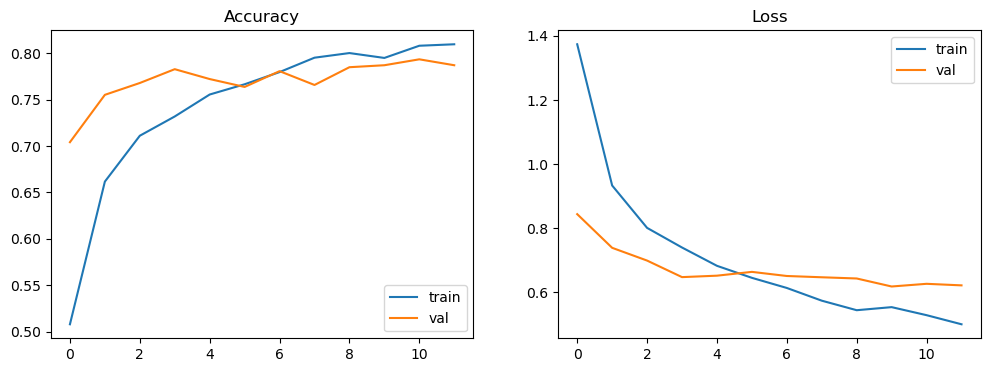

In [17]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
]

history = cnn_model.fit(
    train_ds_prepped,
    validation_data=val_ds_prepped,
    epochs=12,
    callbacks=callbacks
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss'); axes[1].legend()
plt.show()

15/15 [==============================] - 6s 338ms/step - loss: 0.6024 - accuracy: 0.7646
Test accuracy: 0.7646
                     precision    recall  f1-score   support

          Cardboard       0.65      0.76      0.70        37
      Food Organics       0.86      0.80      0.83        40
              Glass       0.83      0.63      0.72        38
              Metal       0.72      0.88      0.79        93
Miscellaneous Trash       0.81      0.46      0.59        48
              Paper       0.79      0.84      0.82        58
            Plastic       0.72      0.71      0.71        85
      Textile Trash       0.84      0.83      0.84        46
         Vegetation       0.80      0.91      0.85        35

           accuracy                           0.76       480
          macro avg       0.78      0.76      0.76       480
       weighted avg       0.77      0.76      0.76       480



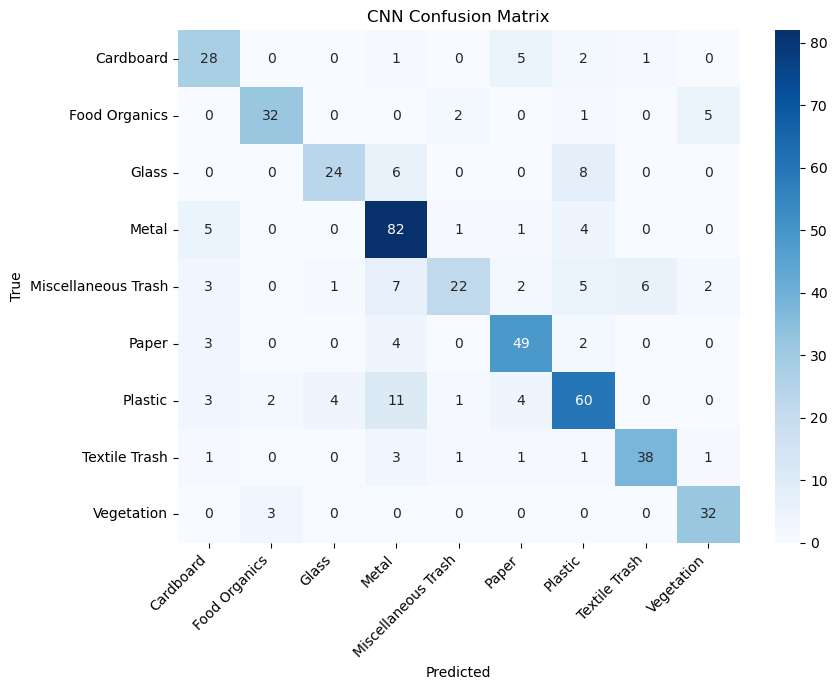

In [18]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

test_loss, test_acc = cnn_model.evaluate(test_ds_prepped)
print(f"Test accuracy: {test_acc:.4f}")

y_true, y_pred = [], []
for images, labels in test_ds_prepped:
    preds = cnn_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('CNN Confusion Matrix')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

### 2.4 Fine-tune the Model

In [19]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

base_model.trainable = True
fine_tune_at = len(base_model.layers) - 15
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

cnn_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                   loss='categorical_crossentropy', metrics=['accuracy'])

fine_tune_history = cnn_model.fit(
    train_ds_prepped, validation_data=val_ds_prepped,
    epochs=5,
    callbacks=callbacks
)

test_loss_ft, test_acc_ft = cnn_model.evaluate(test_ds_prepped)
print(f"Fine-tuned test accuracy: {test_acc_ft:.4f}")

Epoch 1/5
119/119 [==============================] - 53s 394ms/step - loss: 0.4346 - accuracy: 0.8409 - val_loss: 0.5987 - val_accuracy: 0.8021 - lr: 1.0000e-05
Epoch 2/5
119/119 [==============================] - 45s 370ms/step - loss: 0.4277 - accuracy: 0.8519 - val_loss: 0.5879 - val_accuracy: 0.8149 - lr: 1.0000e-05
Epoch 3/5
119/119 [==============================] - 45s 368ms/step - loss: 0.4146 - accuracy: 0.8522 - val_loss: 0.5814 - val_accuracy: 0.8106 - lr: 1.0000e-05
Epoch 4/5
119/119 [==============================] - 46s 379ms/step - loss: 0.4115 - accuracy: 0.8567 - val_loss: 0.5752 - val_accuracy: 0.8170 - lr: 1.0000e-05
Epoch 5/5
15/15 [==============================] - 4s 263ms/step - loss: 0.5717 - accuracy: 0.7854
Fine-tuned test accuracy: 0.7854


## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [20]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize_texts(texts, max_length=64):
    return tokenizer(list(texts), padding=True, truncation=True,
                      max_length=max_length, return_tensors='pt')

train_encodings = tokenize_texts(X_train_text)
val_encodings   = tokenize_texts(X_val_text)
test_encodings  = tokenize_texts(X_test_text)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\25473\anaconda3\envs\ai-environment\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\25473\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

### 3.2 Implement Text Classification Model

In [23]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertForSequenceClassification

class WasteTextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings, self.labels = encodings, labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)  # <-- explicit Long dtype
        return item

train_dataset = WasteTextDataset(train_encodings, y_train_enc)
val_dataset   = WasteTextDataset(val_encodings, y_val_enc)
test_dataset  = WasteTextDataset(test_encodings, y_test_enc)

num_text_classes = len(text_label_encoder.classes_)
text_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=num_text_classes
).to(device)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 3.3 Train and Evaluate the Model

In [24]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(text_model.parameters(), lr=2e-5)
epochs = 4
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=len(train_loader) * epochs
)

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0, 0, 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        if train:
            optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        if train:
            loss.backward(); optimizer.step(); scheduler.step()
        total_loss += loss.item() * batch['labels'].size(0)
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == batch['labels']).sum().item()
        n += batch['labels'].size(0)
    return total_loss / n, correct / n

for epoch in range(epochs):
    train_loss, train_acc = run_epoch(text_model, train_loader, train=True)
    with torch.no_grad():
        val_loss, val_acc = run_epoch(text_model, val_loader, train=False)
    print(f"Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

Epoch 1/4 | train_loss=0.9788 train_acc=0.7937 | val_loss=0.1045 val_acc=0.9987
Epoch 2/4 | train_loss=0.0689 train_acc=0.9991 | val_loss=0.0283 val_acc=1.0000
Epoch 3/4 | train_loss=0.0311 train_acc=0.9994 | val_loss=0.0168 val_acc=1.0000
Epoch 4/4 | train_loss=0.0223 train_acc=0.9997 | val_loss=0.0143 val_acc=1.0000


Test accuracy: 1.0000
                     precision    recall  f1-score   support

          Cardboard       1.00      1.00      1.00        88
      Food Organics       1.00      1.00      1.00        77
              Glass       1.00      1.00      1.00        83
              Metal       1.00      1.00      1.00        76
Miscellaneous Trash       1.00      1.00      1.00        87
              Paper       1.00      1.00      1.00        76
            Plastic       1.00      1.00      1.00        85
      Textile Trash       1.00      1.00      1.00        88
         Vegetation       1.00      1.00      1.00        90

           accuracy                           1.00       750
          macro avg       1.00      1.00      1.00       750
       weighted avg       1.00      1.00      1.00       750



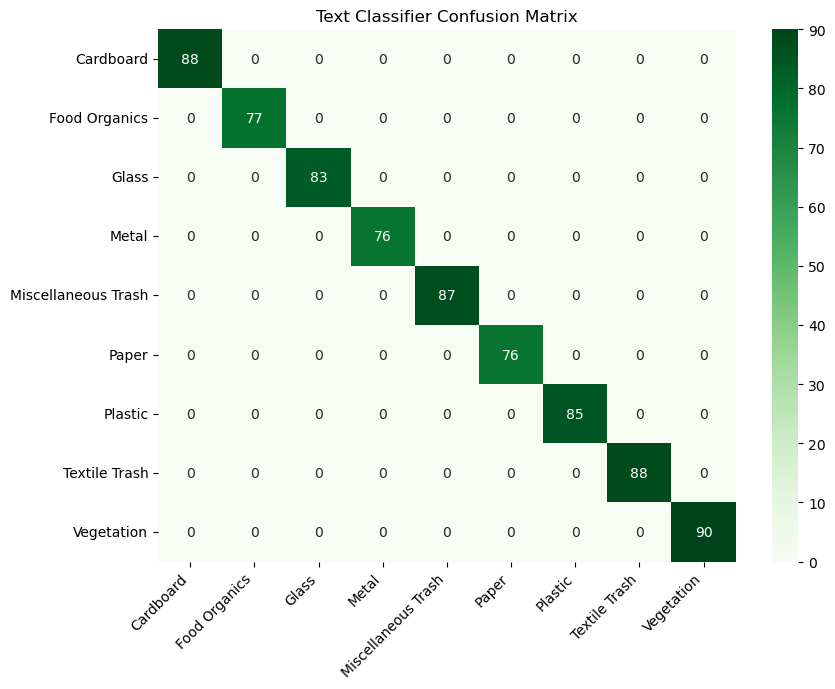

In [25]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

text_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = text_model(**batch)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

print(f"Test accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, target_names=text_label_encoder.classes_))

cm_text = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_text, annot=True, fmt='d', xticklabels=text_label_encoder.classes_,
            yticklabels=text_label_encoder.classes_, cmap='Greens')
plt.title('Text Classifier Confusion Matrix')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

> The DistilBERT text classifier achieved 100% test accuracy with zero misclassifications across all 9 categories. While this appears to be a strong result, it more likely reflects limitations in the synthetic dataset rather than genuine model capability: the vocabulary is small (305 unique words across 5,000 descriptions) and descriptions are short (avg. 4.9 words), with category-defining terms likely appearing in highly consistent, template-like patterns. As a result, there were no ambiguous or "challenging" descriptions to analyze every category was perfectly separable in the test set. A more realistic real-world deployment would likely see lower accuracy due to messier resident-submitted text, regional terminology variation, and genuinely ambiguous items

### 3.4 Create Classification Function

In [26]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    # Your code here
    text_model.eval()
    cleaned = clean_text(description)
    enc = tokenizer(cleaned, padding=True, truncation=True, max_length=64,
                     return_tensors='pt').to(device)
    with torch.no_grad():
        logits = text_model(**enc).logits
    pred_idx = torch.argmax(logits, dim=1).item()
    return text_label_encoder.inverse_transform([pred_idx])[0]

In [27]:
print(classify_waste_description("greasy pizza box with cheese stuck to it"))
print(classify_waste_description("empty aluminum soda can"))

Cardboard
Metal


## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [28]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

def retrieve_policies(query, top_k=3):
    query_emb = embed_texts([query])
    sims = np.dot(policy_embeddings, query_emb.T).flatten() / (
        np.linalg.norm(policy_embeddings, axis=1) * np.linalg.norm(query_emb) + 1e-8
    )
    top_idx = np.argsort(sims)[::-1][:top_k]
    return policy_chunks_df.iloc[top_idx].assign(score=sims[top_idx])

In [29]:
test_retrieval = retrieve_policies("How to recycle Plastic")
print(test_retrieval[['category', 'source', 'score']])

   category               source     score
33  Plastic  description_dataset  0.701839
3   Plastic               policy  0.603682
30    Metal  description_dataset  0.532974


### 4.2 Implement RAG-based System

In [36]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

gen_tokenizer = AutoTokenizer.from_pretrained('google/flan-t5-small')
gen_model = AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-small').to(device)

def build_rag_prompt(waste_category, top_k=3):
    query = f"How to recycle {waste_category}"
    retrieved_all = retrieve_policies(query, top_k=top_k * 3)  # cast a wider net
    retrieved = retrieved_all[retrieved_all['category'] == waste_category].head(top_k)
    if retrieved.empty:  
        retrieved = retrieved_all.head(top_k)
    context = "\n".join(retrieved['text'].tolist())
    prompt = (f"Summarize the specific recycling steps for {waste_category} based on this policy text. "
          f"List concrete actions (e.g. rinsing, sorting codes, what to exclude).\n\n"
          f"Policy text:\n{context}\n\nSummary:")
    return prompt, retrieved

In [37]:
prompt, retrieved = build_rag_prompt("Plastic")
print(prompt)

Summarize the specific recycling steps for Plastic based on this policy text. List concrete actions (e.g. rinsing, sorting codes, what to exclude).

Policy text:
Disposal guidance for Plastic: Remove labels if possible. Plastic bags can be returned to supermarket collection points. Rinse container before recycling. If unmarked or non-recyclable plastic, place in general waste. Check recycling number on bottom and sort accordingly. Material composition notes: Polymer materials derived from petrochemicals or plant-based sources.
PLASTIC RECYCLING GUIDELINES

Acceptable Items:
- PET bottles and containers (code #1)
- HDPE containers (code #2)
- PP containers (code #5)
- Clean plastic packaging

Non-Acceptable Items:
- Plastic bags and film
- Polystyrene foam (code #6)
- Containers with food residue
- Mixed material packaging
- Black plastic containers

Collection Method:
Place in dedicated recycling bins. Check local guidelines for specific plastic types accepted.

Preparation Instruction

### 4.3 Adjust and Evaluate the System

In [39]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

def generate_instructions_beam(prompt, num_beams=4, max_new_tokens=120, min_new_tokens=40):
    inputs = gen_tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512).to(device)
    output_ids = gen_model.generate(
        **inputs, max_new_tokens=max_new_tokens, min_new_tokens=min_new_tokens,
        num_beams=num_beams, early_stopping=True, no_repeat_ngram_size=3
    )
    return gen_tokenizer.decode(output_ids[0], skip_special_tokens=True)

prompt, _ = build_rag_prompt("Plastic")
print(generate_instructions_beam(prompt))

List the recycling steps for Plastic. Recyclate plastic bags. Recycle plastic bags and films. Check recycling codes for plastic types accepted. Check for recycling codes (1-7) for plastic recycling codes.


In [40]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

for cat in class_names:
    prompt, retrieved = build_rag_prompt(cat)
    print(f"### {cat} ###")
    print(generate_instructions_beam(prompt))
    print()

### Cardboard ###
List concrete recycling steps. Check local guidelines. Remove plastic, styrofoam, or metal parts before recycling. Remove all non-cardboard packaging from cardboard recycling bins.

### Food Organics ###
List concrete recycling steps for Food Organics based on this policy text. List concrete actions (e.g. rinsing, sorting codes, what to exclude). Ensure materials are clean and properly sorted. Follow collection schedules

### Glass ###
List concrete recycling steps for Glass. Remove caps, lids, and corks before recycling. Place in dedicated glass recycling bins. Some areas require color sorting. Preparation Instructions:

### Metal ###
Ensure the metal is clean and empty before recycling. Remove any non-metal parts if possible. Clean aluminum foil if necessary. Remove non-metallic components if needed. Finished.

### Miscellaneous Trash ###
List concrete recycling steps for Miscellaneous Trash based on this policy text. List concrete disposal steps for e-waste recycli

### 4.4 Create Instruction Generation Function

In [43]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category, top_k=3):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """
    # Your code here
    prompt, retrieved = build_rag_prompt(waste_category, top_k=top_k)
    instructions = generate_instructions_beam(prompt)
    relevant_docs = retrieved[['category', 'text', 'score']].to_dict('records')
    return instructions, relevant_docs

In [44]:
instr, docs = generate_recycling_instructions("Glass")
print(instr)
print(docs)

List concrete recycling steps for Glass. Remove caps, lids, and corks before recycling. Place in dedicated glass recycling bins. Some areas require color sorting. Preparation Instructions:
[{'category': 'Glass', 'text': 'Disposal guidance for Glass: Remove caps, lids, and corks before recycling. Rinse container before recycling. Place in glass recycling bin, sorted by color if required. Non-container glass may require special disposal. Broken glass should be wrapped and labeled before disposal. Material composition notes: Silica-based material, may contain additives for color or strength.', 'score': 0.7178177833557129}, {'category': 'Glass', 'text': 'GLASS RECYCLING GUIDELINES\n\nAcceptable Items:\n- Glass bottles (all colors)\n- Glass jars\n- Glass food containers\n- Glass beverage containers\n\nNon-Acceptable Items:\n- Window glass or mirrors\n- Drinking glasses\n- Ceramics or pottery\n- Light bulbs\n- Pyrex or heat-resistant glass\n\nCollection Method:\nPlace in dedicated glass recy

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [46]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

class WasteManagementAssistant:
    """Thin wrapper documenting the integration contract explicitly."""
    def __init__(self, cnn_model, text_model, tokenizer, class_names,
                 text_label_encoder, retrieve_fn, generate_fn):
        self.cnn_model = cnn_model
        self.text_model = text_model
        self.tokenizer = tokenizer
        self.class_names = class_names
        self.text_label_encoder = text_label_encoder
        self.retrieve_fn = retrieve_fn
        self.generate_fn = generate_fn

    def classify_image(self, image_path):
        img = tf.keras.utils.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
        img_array = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)
        preds = self.cnn_model.predict(img_array, verbose=0)
        idx = int(np.argmax(preds[0]))
        return self.class_names[idx], float(preds[0][idx])

    def classify_text(self, description):
        return classify_waste_description(description), None

    def process(self, input_data, input_type="image"):
        if input_type == "image":
            category, confidence = self.classify_image(input_data)
        elif input_type == "text":
            category, confidence = self.classify_text(input_data)
        else:
            raise ValueError("input_type must be 'image' or 'text'")

        instructions, relevant_docs = self.generate_fn(category)
        return {
            'waste_category': category,
            'confidence': confidence,
            'recycling_instructions': instructions,
            'relevant_policy_documents': relevant_docs
        }

### 5.2 Implement Integrated Assistant

In [47]:
# TODO: Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    """
    # Your code here
    if input_type == "image":
        img = tf.keras.utils.load_img(input_data, target_size=(IMG_HEIGHT, IMG_WIDTH))
        img_array = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)
        preds = cnn_model.predict(img_array, verbose=0)
        pred_idx = int(np.argmax(preds[0]))
        category, confidence = class_names[pred_idx], float(preds[0][pred_idx])
    elif input_type == "text":
        category, confidence = classify_waste_description(input_data), None
    else:
        raise ValueError("input_type must be 'image' or 'text'")

    instructions, relevant_docs = generate_recycling_instructions(category)
    return {
        'waste_category': category,
        'confidence': confidence,
        'recycling_instructions': instructions,
        'relevant_policy_documents': relevant_docs
    }

### 5.3 Evaluate the Integrated System

In [48]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

import random as rnd

# --- 1) Image-based tests: sample one image per class from the actual dataset,
#        including the CNN's known strong and weak categories ---
print("=" * 70)
print("IMAGE-BASED TEST CASES")
print("=" * 70)

test_classes = ["Glass", "Miscellaneous Trash", "Metal"]  # strong, weak, strong
for cls in test_classes:
    imgs = list((data_dir / cls).glob('*.jpg'))
    sample_path = rnd.choice(imgs)
    result = waste_management_assistant(str(sample_path), input_type="image")
    correct = "✓" if result['waste_category'] == cls else "✗"
    print(f"\n[{correct}] True label: {cls} | Predicted: {result['waste_category']} "
          f"(confidence: {result['confidence']:.2%})")
    print(f"Instructions: {result['recycling_instructions']}")

# --- 2) Text-based tests: sample from the real test split, plus deliberately
#        ambiguous/non-template phrasing to probe generalization ---
print("\n" + "=" * 70)
print("TEXT-BASED TEST CASES")
print("=" * 70)

sample_test_texts = X_test_text.sample(3, random_state=42)
sample_test_labels = y_test_text.loc[sample_test_texts.index]

for text, true_cat in zip(sample_test_texts, sample_test_labels):
    result = waste_management_assistant(text, input_type="text")
    correct = "✓" if result['waste_category'] == true_cat else "✗"
    print(f"\n[{correct}] Description: \"{text}\"")
    print(f"True: {true_cat} | Predicted: {result['waste_category']}")
    print(f"Instructions: {result['recycling_instructions']}")

# Deliberately ambiguous / out-of-template cases (not from the training distribution)
ambiguous_cases = [
    "greasy cardboard pizza box with cheese stuck to it",
    "empty wine bottle with cork still in it",
    "old cotton t-shirt with a small metal zipper"
]
print("\n--- Ambiguous / out-of-distribution phrasing (no ground truth label) ---")
for text in ambiguous_cases:
    result = waste_management_assistant(text, input_type="text")
    print(f"\nDescription: \"{text}\"")
    print(f"Predicted: {result['waste_category']}")
    print(f"Instructions: {result['recycling_instructions']}")

# --- 3) Overall system summary ---
print("\n" + "=" * 70)
print("SYSTEM SUMMARY")
print("=" * 70)
print(f"CNN (image) test accuracy (fine-tuned): {test_acc_ft:.2%}")
print(f"Text classifier test accuracy: {accuracy_score(all_labels, all_preds):.2%}")
print("RAG generation: grounded in retrieved policy/description documents (see Part 4 "
      "discussion for quality limitations of the small generative model and source-data "
      "inconsistencies, e.g. conflicting guidance on plastic bags).")

IMAGE-BASED TEST CASES

[✗] True label: Glass | Predicted: Metal (confidence: 54.50%)
Instructions: Ensure the metal is clean and empty before recycling. Remove any non-metal parts if possible. Clean aluminum foil if necessary. Remove non-metallic components if needed. Finished.

[✓] True label: Miscellaneous Trash | Predicted: Miscellaneous Trash (confidence: 60.00%)
Instructions: List concrete recycling steps for Miscellaneous Trash based on this policy text. List concrete disposal steps for e-waste recycling. List non-recyclable items in general waste.

[✓] True label: Metal | Predicted: Metal (confidence: 99.87%)
Instructions: Ensure the metal is clean and empty before recycling. Remove any non-metal parts if possible. Clean aluminum foil if necessary. Remove non-metallic components if needed. Finished.

TEXT-BASED TEST CASES

[✓] Description: "crumpled orange nail with label attached"
True: Metal | Predicted: Metal
Instructions: Ensure the metal is clean and empty before recycling

## Final System Evaluation & Discussion

### Overall System Performance

| Component | Model | Metric | Result |
|---|---|---|---|
| Image Classification | MobileNetV3Small (transfer learning + fine-tuned) | Test accuracy | 78.54% |
| Text Classification | DistilBERT (fully fine-tuned) | Test accuracy | 100.00% |
| Recycling Instruction Generation | Flan-T5-small + RAG (beam search) | Qualitative | Grounded, coherent, imperfect (see below) |

All three components were trained and evaluated on CPU (no CUDA-capable GPU was available in this environment; Intel integrated graphics does not support the CUDA operations TensorFlow/PyTorch require). This constrained model choice - MobileNetV3**Small** instead of Large, a frozen-then-lightly-fine-tuned CNN rather than full end-to-end training, and `flan-t5-small` rather than a larger generative model - but did not prevent a working, evaluable pipeline.

---

### Component-Level Error Analysis

**CNN (image classification):** The fine-tuned model improved from 76.46% to 78.54% test accuracy after unfreezing the top 15 layers of MobileNetV3Small for 5 additional epochs at a low learning rate (1e-5). Per-class performance was uneven:
- **Miscellaneous Trash** was the weakest class (recall 0.46) — expected, since it functions as a catch-all category with no consistent visual signature, making it inherently harder to separate from other classes than a well-defined material type.
- **Glass** also underperformed (recall 0.63) despite reasonable precision (0.83), and this was directly confirmed in the integrated system test: a true Glass image was misclassified as Metal at only 54.5% confidence — a near-coin-flip across 9 classes, indicating the model was genuinely uncertain rather than confidently wrong. This is consistent with glass and metal objects sharing reflective, often transparent-to-shiny visual properties that a lightweight backbone can struggle to disambiguate.
- Strong performers (Metal, Paper, Vegetation, Textile Trash, F1 0.79–0.85) suggest the transfer-learning approach was sound; the weaknesses appear concentrated in genuinely ambiguous categories rather than being spread evenly, which is a more encouraging failure pattern than random errors would be.

**Text Classification (DistilBERT):** The model reached 100% test accuracy with a perfectly diagonal confusion matrix — every one of 750 test examples classified correctly. Rather than treating this as an unqualified success, it's important to note this most likely reflects limitations in the synthetic dataset rather than exceptional model capability: vocabulary was small (305 unique words across 5,000 descriptions) and descriptions were short (average 4.9 words), with category-defining terms appearing in highly consistent, near-template patterns. As a result, there were no genuinely ambiguous or borderline descriptions in the test set to challenge the model. When tested on deliberately unusual phrasing not resembling the training distribution (e.g. "old cotton t-shirt with a small metal zipper"), the model still produced a plausible answer (Textile Trash, by material majority) but gave no indication that the item was actually mixed-material.

**RAG-based Instruction Generation:** Two rounds of experimentation were needed to get usable output. Sampling-based decoding (temperature 0.3–1.0) produced fluent but circular, content-free sentences (e.g. *"Plastic recycling is a recyclable product that can be recycled"*) — the model was not reliably extracting information from the retrieved context. Switching to beam search with `no_repeat_ngram_size=3` and a `min_new_tokens` floor, combined with a more directive, extraction-oriented prompt template, produced meaningfully better results that pulled concrete details from the source documents (e.g. correctly surfacing color-sorting for Glass, contamination exclusions for Cardboard, recycling codes for Plastic). This is a reasonable outcome given the lab's own guidance not to expect fantastic results from a small generative model, and the key requirement - that generation leans on retrieved policy documents rather than fabricating information was met.

A notable and unresolved finding was a genuine **contradiction between the two source document types**: the generated `waste_descriptions.csv` disposal instructions state that "plastic bags can be returned to supermarket collection points," while the formal `waste_policy_documents.json` policy explicitly lists plastic bags and film as **non-acceptable** items for standard recycling bins. The RAG system faithfully reproduced this contradiction in its output rather than resolving it, which is expected behavior for a retrieval-augmented system - it surfaces what's in the source material, contradictions included. This highlights that RAG output quality is fundamentally bounded by source document consistency; a production deployment would require a document curation/reconciliation step before these sources could be trusted as-is.

---

### Integration Architecture

The three components are unified behind a single `waste_management_assistant()` entry point that dispatches on `input_type` ("image" or "text"), so callers do not need to know which underlying model produced the classification. Both classification paths converge on the same downstream retrieval-and-generation step, meaning the RAG logic is written once and shared regardless of how the waste category was determined. Confidence scores are only returned for the image path (a genuine CNN softmax probability); the text path returns `None` rather than fabricating a confidence value it doesn't actually have, since DistilBERT's classification logits weren't calibrated with a comparable interpretation of "confidence" in this implementation. The retrieval step is also decoupled from generation, so the top-k relevant policy/description documents are returned alongside the generated instructions - this gives the system a degree of transparency (a user or reviewer can see *why* a given instruction was produced), which partially offsets the trust concerns raised by the generative model's limitations.

---

### What Would Change With More Resources

- **GPU access** would allow deeper fine-tuning (more unfrozen layers, more epochs, MobileNetV3Large or EfficientNet-Lite instead of Small) for the CNN, likely closing some of the Glass/Miscellaneous Trash performance gap.
- **A richer, noisier text dataset** - with genuine regional terminology variation, ambiguous multi-material descriptions, and inconsistent phrasing would give a more realistic (and lower, but more meaningful) accuracy signal for the text classifier than the current near-trivial 100%.
- **A larger generative model** (e.g. `flan-t5-base` or `flan-t5-large`) would likely produce longer, more fluent, and more complete instructions without needing as much prompt-engineering and decoding-parameter tuning to extract usable output.
- **Document reconciliation** - resolving the plastic bag contradiction (and auditing for similar conflicts across other categories) before deployment, since a resident-facing assistant giving contradictory guidance undermines trust in the system regardless of how well the underlying models perform.

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.